# Масштабирование признаков в pandas

## Подготовка данных

Представим, что вам нужно предсказать, заинтересуется ли клиент продуктом компании. Для этого используется набор данных с несколькими признаками — характеристиками клиентов.

Разберём, как каждый из них может влиять на поведение.

Возраст. Помогает понять, на каком жизненном этапе находится клиент:

- Молодые клиенты (18–30 лет) чаще интересуются дебетовыми картами, кредитами на образование и мобильными приложениями.
- Люди среднего возраста — ипотекой, инвестиционными продуктами, накопительными программами.
- Пожилые клиенты — пенсионными услугами, страхованием жизни и сберегательными вкладами.

Стаж работы. Отражает финансовую стабильность клиента:
- Клиенты с небольшим стажем менее предсказуемы, но им можно предложить стартовые продукты: первые кредиты, простые карты.
- Долгий стаж говорит о стабильности — можно рекомендовать инвестиции, ипотеку, премиальные пакеты.

Доход. Один из ключевых факторов при подборе продукта:
- Клиенты с низким доходом вряд ли заинтересуются премиальными услугами, но им подойдут простые кредиты или сберегательные счета.
- Высокий доход — возможность предложить персональное обслуживание, инвестиционные продукты, премиальные карты.

Количество посещений отделения в месяц. Отражает уровень вовлечённости клиента в офлайн-обслуживание:
- Часто посещающие клиенты могут быть более активными, им стоит предложить персональные консультации или офлайн-услуги.
- Редко посещающие чаще выбирают цифровые каналы — им подойдут онлайн-продукты, мобильный банкинг, автоплатежи.

Каждый из четырёх признаков имеет свой диапазон значений и измеряется в разных единицах. Например, доход выражается в сотнях тысяч рублей, а количество посещений отделения — всего от 0 до 10 в месяц. Если не привести признаки к единому масштабу, модель будет уделять больше внимания признакам с большими значениями (например, доходу) и игнорировать остальные. Масштабирование нормализует разброс значений и поможет модели лучше обучаться.

### Предобработка данных


Cоздадим искусственный набор данных для 1000 клиентов банка. Каждый клиент описывается четырьмя признаками:
- возраст — от 18 до 70 лет;
- стаж работы — от 0 до 600 месяцев;
- доход — от 20 000 до 500 000 рублей в месяц;
- количество посещений отделения — от 0 до 10 в месяц.

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)  # Для воспроизводимости

# Количество клиентов
n = 1000

# Создаём данные
data = {
    'age': np.random.randint(18, 70, size=n),  # Возраст от 18 до 70 лет включительно
    'experience_months': np.random.randint(0, 600, size=n),  # Стаж от 0 до 600 месяцев
    'income_rub': np.random.randint(20000, 500000, size=n),  # Доход от 20k до 500k рублей
    'visits_count': np.random.randint(0, 10, size=n)  # Кол-во посещений от 0 до 10 в месяц
}

# Создаём DataFrame
df = pd.DataFrame(data)

# Выводим первые строки
print("Исходные данные:\n", df)

Исходные данные:
      age  experience_months  income_rub  visits_count
0     56                 14      424772             9
1     69                191      440814             1
2     46                484      162635             2
3     32                 27       66819             6
4     60                 38      355914             5
..   ...                ...         ...           ...
995   60                220      408612             3
996   64                153      103457             3
997   62                 11       34357             6
998   35                132      131672             9
999   55                303      350817             8

[1000 rows x 4 columns]


#### Визуализация данных

Чтобы лучше понять, как распределены признаки и насколько они отличаются по масштабу, построим диаграмму размаха или «ящик с усами» — boxplot.

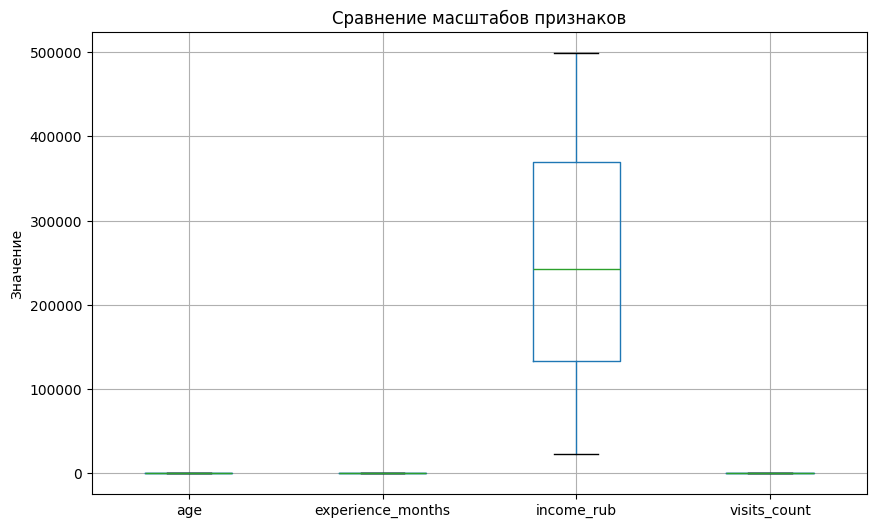

In [2]:
import matplotlib.pyplot as plt

# Устанавливаем размер фигуры (ширина 10, высота 6)
plt.figure(figsize=(10, 6))

# Строим boxplot (диаграмму размаха) для всех указанных признаков
df.boxplot(column=['age', 'experience_months', 'income_rub', 'visits_count'])

# Заголовок графика
plt.title('Сравнение масштабов признаков')

# Подпись оси Y
plt.ylabel('Значение')

# Показываем график
plt.show()

Признак `income_rub` сильно выделяется: его значения распределены гораздо шире (длинная коробка и усы) и находятся на значительно более высоком уровне (медиана выше).

Это значит, что у дохода иной масштаб и большой разброс, поэтому без предварительного масштабирования он будет доминировать над остальными признаками в модели.

#### Разбиение данных на выборки

Чтобы протестироваить маштабирование - не будем выделять валидационную выборку для простоты

In [3]:
from sklearn.model_selection import train_test_split

# Разделяем данные: 80% — для обучения, 20% — для тестирования
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Выводим размеры выборок
print(f"Размер обучающей выборки: {train_df.shape}")
print(f"Размер тестовой выборки: {test_df.shape}")

Размер обучающей выборки: (800, 4)
Размер тестовой выборки: (200, 4)


После разделения данных на обучающую и тестовую выборки можно проверить, что распределение ключевых признаков в них примерно одинаковое. Для этого посмотрим на распределение признака возраст ( age ) в обеих выборках.

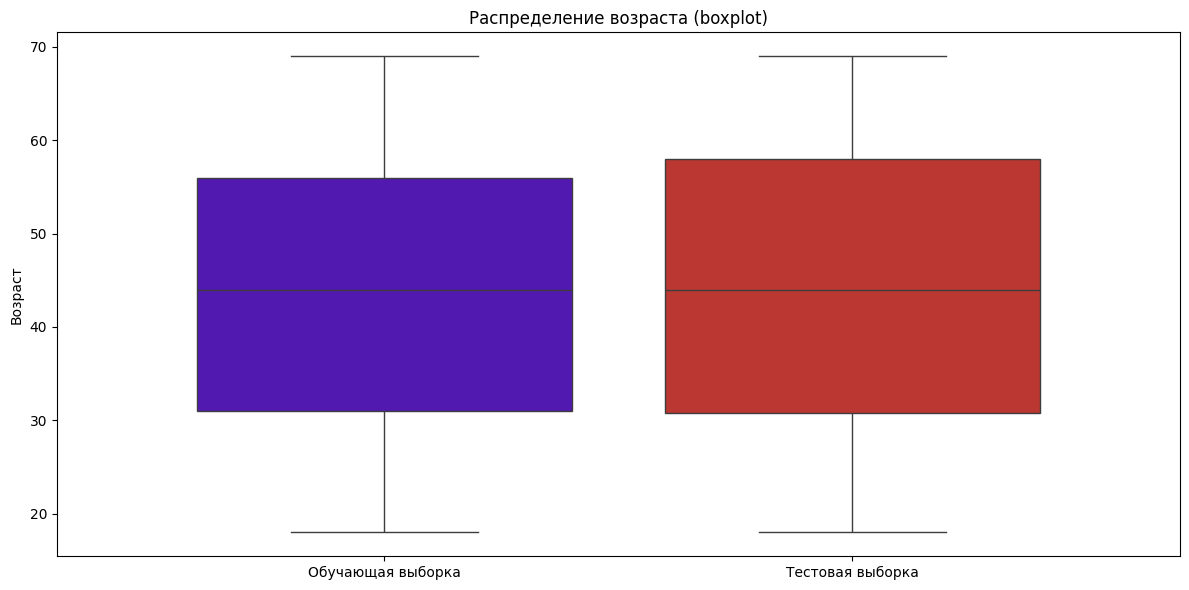

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Устанавливаем размер
plt.figure(figsize=(12, 6))

# Добавляем .values, чтобы Seaborn не группировал данные по одинаковому имени 'age'
sns.boxplot(data=[train_df['age'].values, test_df['age'].values], palette=['#4b00ca', '#d1241a'])

# Устанавливаем границы и подписи
plt.xlim(-0.7, 1.7)
plt.xticks([0, 1], ['Обучающая выборка', 'Тестовая выборка'])
plt.title('Распределение возраста (boxplot)')
plt.ylabel('Возраст')

plt.tight_layout()
plt.show()


Видно что распределение и порядок данных в обоих выборках одинаковый.

## Реализация масштабирования


Важное правило — все статистики считаем только по обучающей выборке.

### Стандартизация

In [5]:
# df (DataFrame) задан ранее

# Разделяем данные: 80% — для обучения, 20% — для тестирования
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Вычисляем среднее и стандартное отклонение по обучающей выборке
mean = train_df.mean()
std = train_df.std()

# Применяем стандартизацию
train_standardized = (train_df - mean) / std
test_standardized = (test_df - mean) / std

print("Сравнение статистик ДО и ПОСЛЕ стандартизации:\n")
for col in train_df.columns:
    original_min = train_df[col].min()
    original_max = train_df[col].max()
    original_mean = train_df[col].mean()
    
    standardized_min = train_standardized[col].min()
    standardized_max = train_standardized[col].max()
    standardized_mean = train_standardized[col].mean()
    
    print(f"{col}:\n"
          f"  Было:    min={original_min:.2f}, max={original_max:.2f}, mean={original_mean:.2f}\n"
          f"  Стало:   min={standardized_min:.2f}, max={standardized_max:.2f}, mean={standardized_mean:.2f}\n")

Сравнение статистик ДО и ПОСЛЕ стандартизации:

age:
  Было:    min=18.00, max=69.00, mean=43.79
  Стало:   min=-1.75, max=1.71, mean=-0.00

experience_months:
  Было:    min=0.00, max=598.00, mean=286.30
  Стало:   min=-1.65, max=1.79, mean=0.00

income_rub:
  Было:    min=23191.00, max=498883.00, mean=250701.28
  Стало:   min=-1.65, max=1.80, mean=0.00

visits_count:
  Было:    min=0.00, max=9.00, mean=4.41
  Стало:   min=-1.54, max=1.60, mean=-0.00



Для наглядности сравним распределение признаков до и после масштабирования. Построим четыре диаграммы размаха (boxplot):

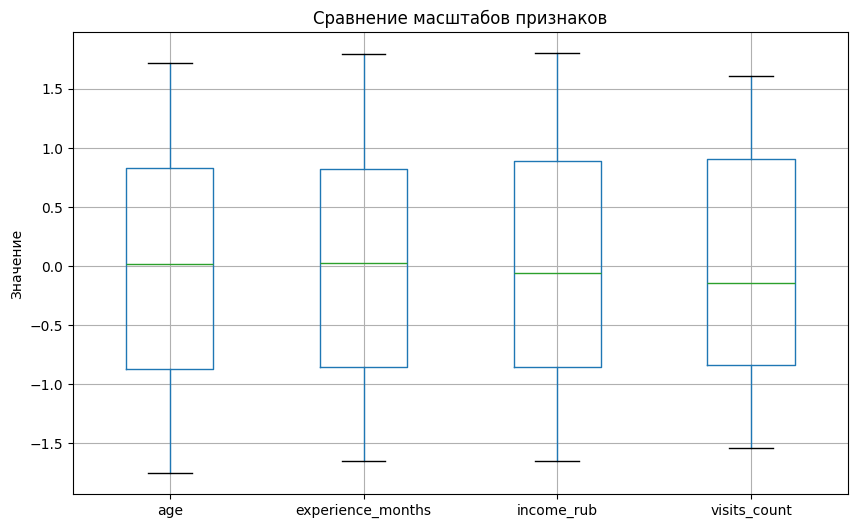

In [6]:
# Устанавливаем размер фигуры (ширина 10, высота 6)
plt.figure(figsize=(10, 6))

# Строим boxplot (диаграмму размаха) для всех указанных признаков
train_standardized.boxplot(column=['age', 'experience_months', 'income_rub', 'visits_count'])

# Заголовок графика
plt.title('Сравнение масштабов признаков')

# Подпись оси Y
plt.ylabel('Значение')

# Показываем график
plt.show()

На основе графиков можно сделать несколько выводов:
1) после масштабирования признаки изменились так, как ожидается: данные центрировались вокруг нуля, а разброс стал сопоставимым для всех признаков;
2) стандартизация приводит распределения к среднему около 0 и стандартному отклонению около 1 — на boxplot это видно по «коробкам» и «усам», расположенным вокруг нуля;
3) на тестовой выборке распределение выглядит похоже, но немного отличается — значит, масштабирование выполнено по параметрам обучающей выборки, а не по тестовой, что является правильным подходом.

### Мини-макс (Min-Max) масштабирование

In [7]:
# df (DataFrame) задан ранее


# Разделяем данные: 80% — для обучения, 20% — для тестирования
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)


# Вычисляем минимум и максимум по обучающей выборке (правильно)
min_vals = train_df.min()
max_vals = train_df.max()

# Масштабируем данные с использованием параметров train
train_minmax = (train_df - min_vals) / (max_vals - min_vals)
test_minmax = (test_df - min_vals) / (max_vals - min_vals)

# Сравнение статистик ДО и ПОСЛЕ масштабирования
print("\nСравнение статистик ДО и ПОСЛЕ Min-Max нормализации:\n")
for col in train_df.columns:
    original_min = train_df[col].min()
    original_max = train_df[col].max()
    original_mean = train_df[col].mean()
    
    scaled_min = train_minmax[col].min()
    scaled_max = train_minmax[col].max()
    scaled_mean = train_minmax[col].mean()
    
    print(f"{col}:\n"
          f"  Было:    min={original_min:.2f}, max={original_max:.2f}, mean={original_mean:.2f}\n"
          f"  Стало:   min={scaled_min:.2f}, max={scaled_max:.2f}, mean={scaled_mean:.2f}\n")


Сравнение статистик ДО и ПОСЛЕ Min-Max нормализации:

age:
  Было:    min=18.00, max=69.00, mean=43.79
  Стало:   min=0.00, max=1.00, mean=0.51

experience_months:
  Было:    min=0.00, max=598.00, mean=286.30
  Стало:   min=0.00, max=1.00, mean=0.48

income_rub:
  Было:    min=23191.00, max=498883.00, mean=250701.28
  Стало:   min=0.00, max=1.00, mean=0.48

visits_count:
  Было:    min=0.00, max=9.00, mean=4.41
  Стало:   min=0.00, max=1.00, mean=0.49



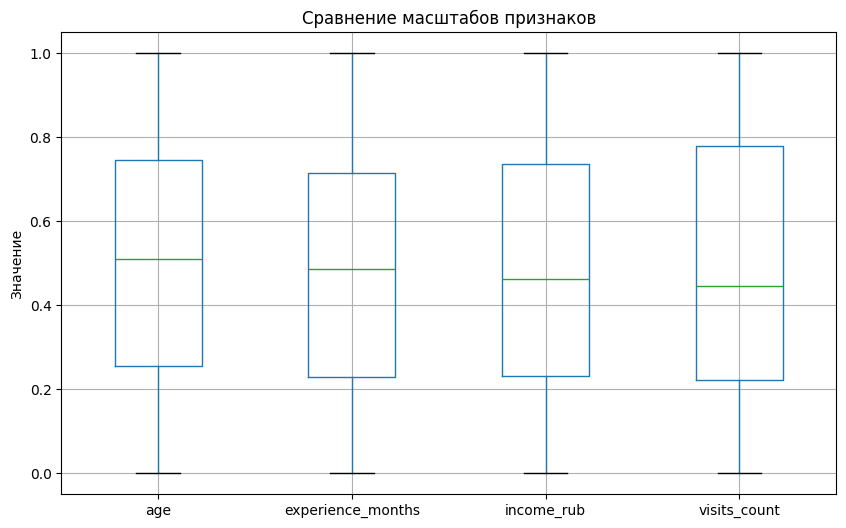

In [8]:
# Устанавливаем размер фигуры (ширина 10, высота 6)
plt.figure(figsize=(10, 6))

# Строим boxplot (диаграмму размаха) для всех указанных признаков
train_minmax.boxplot(column=['age', 'experience_months', 'income_rub', 'visits_count'])

# Заголовок графика
plt.title('Сравнение масштабов признаков')

# Подпись оси Y
plt.ylabel('Значение')

# Показываем график
plt.show()

На boxplot после масштабирования видно, что все признаки находятся примерно в одном диапазоне — при мин-макс масштабировании это [0, 1]. Таким образом, значения не выходят за рамки ожидаемого диапазона.

При сравнении распределений признаков до и после любого типа масштабирования можно заметить ещё один важный момент. 

Масштабирование изменяет только масштаб и сдвиг данных, но не меняет их форму распределения.

<Figure size 1000x600 with 0 Axes>

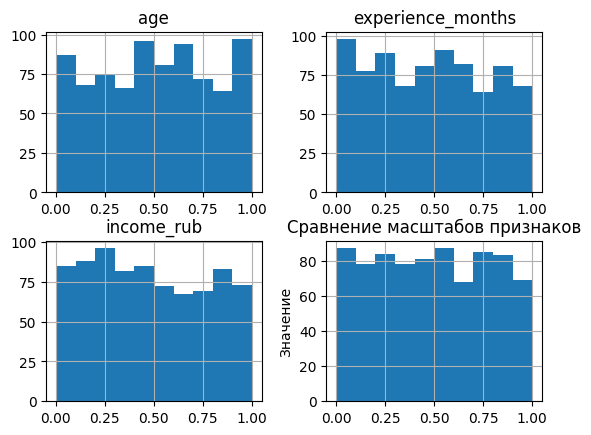

In [9]:
# Устанавливаем размер фигуры (ширина 10, высота 6)
plt.figure(figsize=(10, 6))

# Строим boxplot (диаграмму размаха) для всех указанных признаков
train_minmax.hist(column=['age', 'experience_months', 'income_rub', 'visits_count'])

# Заголовок графика
plt.title('Сравнение масштабов признаков')

# Подпись оси Y
plt.ylabel('Значение')

# Показываем график
plt.show()

<Figure size 1000x600 with 0 Axes>

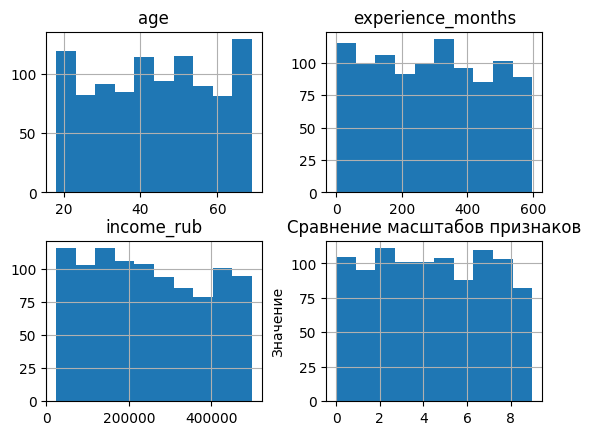

In [10]:
# Устанавливаем размер фигуры (ширина 10, высота 6)
plt.figure(figsize=(10, 6))

# Строим boxplot (диаграмму размаха) для всех указанных признаков
df.hist(column=['age', 'experience_months', 'income_rub', 'visits_count'])

# Заголовок графика
plt.title('Сравнение масштабов признаков')

# Подпись оси Y
plt.ylabel('Значение')

# Показываем график
plt.show()

## Проверка результата

После применения стандартизации или мин-макс нормализации важно проверить, как изменились значения признаков. Для этого можно использовать метод .describe() — он покажет ключевые статистики до и после масштабирования.

In [11]:
print("До масштабирования (train):")
print(train_df.describe())

До масштабирования (train):
              age  experience_months    income_rub  visits_count
count  800.000000         800.000000     800.00000    800.000000
mean    43.786250         286.296250  250701.28000      4.408750
std     14.711002         173.711566  137933.85679      2.863463
min     18.000000           0.000000   23191.00000      0.000000
25%     31.000000         137.500000  132831.50000      2.000000
50%     44.000000         290.500000  242520.50000      4.000000
75%     56.000000         428.000000  373095.25000      7.000000
max     69.000000         598.000000  498883.00000      9.000000


In [12]:
print("\nПосле стандартизации (train):")
print(train_standardized.describe())

print("\nПосле Min-Max масштабирования (train):")
print(train_minmax.describe())


После стандартизации (train):
                age  experience_months    income_rub  visits_count
count  8.000000e+02       8.000000e+02  8.000000e+02  8.000000e+02
mean  -1.776357e-16       7.549517e-17  3.330669e-18 -1.249001e-16
std    1.000000e+00       1.000000e+00  1.000000e+00  1.000000e+00
min   -1.752855e+00      -1.648113e+00 -1.649416e+00 -1.539656e+00
25%   -8.691624e-01      -8.565708e-01 -8.545384e-01 -8.412016e-01
50%    1.452994e-02       2.419960e-02 -5.930944e-02 -1.427467e-01
75%    8.302460e-01       8.157416e-01  8.873381e-01  9.049356e-01
max    1.713938e+00       1.794375e+00  1.799281e+00  1.603390e+00

После Min-Max масштабирования (train):
              age  experience_months  income_rub  visits_count
count  800.000000         800.000000  800.000000    800.000000
mean     0.505613           0.478756    0.478272      0.489861
std      0.288451           0.290488    0.289965      0.318163
min      0.000000           0.000000    0.000000      0.000000
25%      0.

## Как выбросы влияют на масштабирование


В этом примере сравним мин-макс масштабирование и стандартизацию — посмотрим, как они работают при наличии выбросов в данных.

Есть обучающая выборка с доходами ( income_rub ), где одно значение — выраженный выброс: 25_000_000. Цель — понять, как каждый из методов масштабирования справляется с такой ситуацией.

In [ ]:
# Простой набор с выбросом
## Можно поудалять выбосы и посмотреть за изменениями
data_test_extr = pd.DataFrame({
    'income_rub': [30_000, 50_000, 60_000, 70_000, 100_000, 150_000, 25_000_000, 100_000_000]  # последний — выброс
})

# Min-Max масштабирование
data_test_extr['min-max'] = (data_test_extr['income_rub'] - data_test_extr['income_rub'].min()) / (data_test_extr['income_rub'].max() - data_test_extr['income_rub'].min())

# Стандартизация
data_test_extr['standard'] = (data_test_extr['income_rub'] - data_test_extr['income_rub'].mean()) / data_test_extr['income_rub'].std()

# Вывод
print(data_test_extr)

   income_rub   min-max  standard
0       30000  0.000000 -0.445078
1       50000  0.000200 -0.444509
2       60000  0.000300 -0.444225
3       70000  0.000400 -0.443941
4      100000  0.000700 -0.443087
5      150000  0.001200 -0.441666
6    25000000  0.249775  0.264943
7   100000000  1.000000  2.397563


Можно сделать вывод, что мин-макс масштабирование сильно чувствительно к экстремальным выбросам и может «сжать» основную массу данных, делая их практически неразличимыми.

Стандартизация, напротив, учитывает разброс значений и смещает выбросы, сохраняя относительные различия между обычными значениями, что делает её более устойчивой к экстремальным данным.

## Ошибки и защита от утечки


Пример, когда мы потренируем модель и на обучающих данных, и на тестовых.

In [14]:
# Данные
data_leak = {
    'x': [-1, 3, 5, 2, 1, 0, -2, -5, -3],
    'set': ['train', 'train', 'train', 'train', 'train', 'test', 'test', 'test', 'test']
}
df_leak = pd.DataFrame(data_leak)

# Правильная стандартизация — считаем среднее и стандартное отклонение только по train
train_x = df_leak[df_leak['set'] == 'train']['x']
mu_train = train_x.mean()
sigma_train = train_x.std()

df_leak['x_correct'] = (df_leak['x'] - mu_train) / sigma_train

# Неправильная стандартизация — считаем по всей выборке (train + test)
mu_all = df_leak['x'].mean()
sigma_all = df_leak['x'].std()

df_leak['x_leak'] = (df_leak['x'] - mu_all) / sigma_all

print(df_leak[['x', 'set', 'x_correct', 'x_leak']])

   x    set  x_correct    x_leak
0 -1  train  -1.341641 -0.320256
1  3  train   0.447214  0.960769
2  5  train   1.341641  1.601282
3  2  train   0.000000  0.640513
4  1  train  -0.447214  0.320256
5  0   test  -0.894427  0.000000
6 -2   test  -1.788854 -0.640513
7 -5   test  -3.130495 -1.601282
8 -3   test  -2.236068 -0.960769
